In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from pcosense.data import load_clean_data
from pcosense.features import FEATURE_SETS
from pcosense.preprocessing import build_numeric_preprocessor

In [3]:
from sklearn.model_selection import train_test_split

df = load_clean_data()

features = FEATURE_SETS["screening"]
X = df[features]
y = df["PCOS (Y/N)"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (432, 18)
Testing: (109, 18)


In [4]:
best_random_forest = Pipeline([
    ("preprocessor", build_numeric_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=700,
        min_samples_split=5,
        min_samples_leaf=3,
        max_features="log2",
        max_depth=6,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

best_random_forest.fit(X_train, y_train)

print("Selected Random Forest trained successfully")

Selected Random Forest trained successfully


In [5]:
preprocessor = best_random_forest.named_steps["preprocessor"]
forest = best_random_forest.named_steps["model"]

X_test_processed = preprocessor.transform(X_test)

print("Processed test shape:", X_test_processed.shape)

Processed test shape: (109, 18)


In [6]:
explainer = shap.TreeExplainer(forest)
shap_result = explainer(X_test_processed)

print("SHAP values shape:", shap_result.values.shape)

SHAP values shape: (109, 18, 2)


In [7]:
if shap_result.values.ndim == 3:
    base_values = np.asarray(shap_result.base_values)

    if base_values.ndim == 2:
        base_values = base_values[:, 1]

    pcos_explanation = shap.Explanation(
        values=shap_result.values[:, :, 1],
        base_values=base_values,
        data=X_test_processed,
        feature_names=features
    )
else:
    pcos_explanation = shap.Explanation(
        values=shap_result.values,
        base_values=shap_result.base_values,
        data=X_test_processed,
        feature_names=features
    )

print("PCOS explanation shape:", pcos_explanation.values.shape)

PCOS explanation shape: (109, 18)


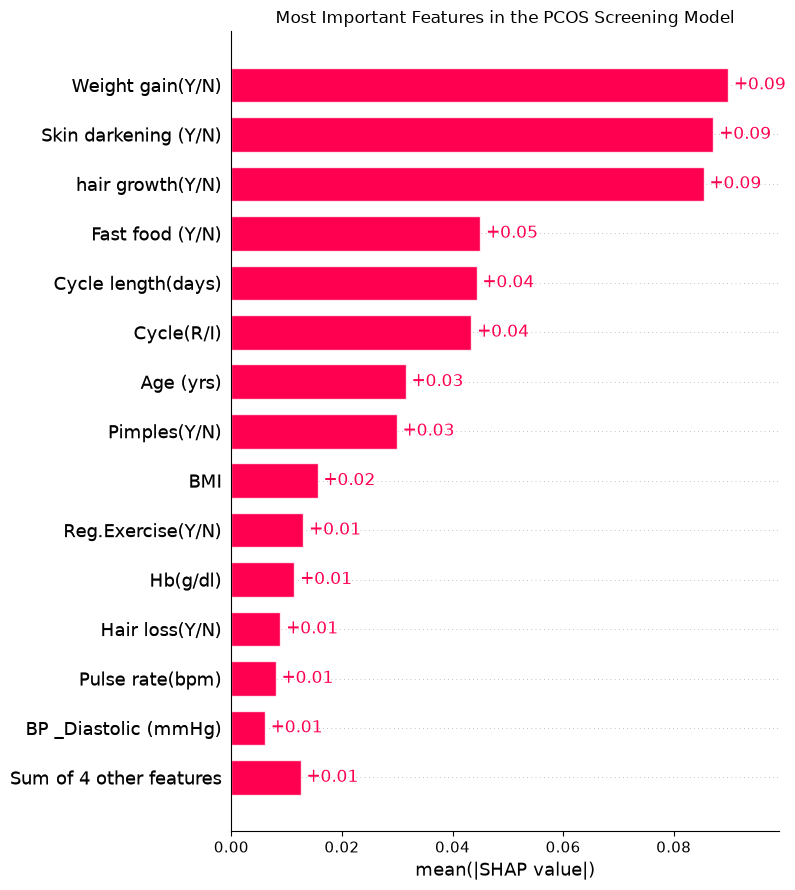

In [8]:
shap.plots.bar(
    pcos_explanation,
    max_display=15,
    show=False
)

plt.title("Most Important Features in the PCOS Screening Model")
plt.tight_layout()
plt.show()

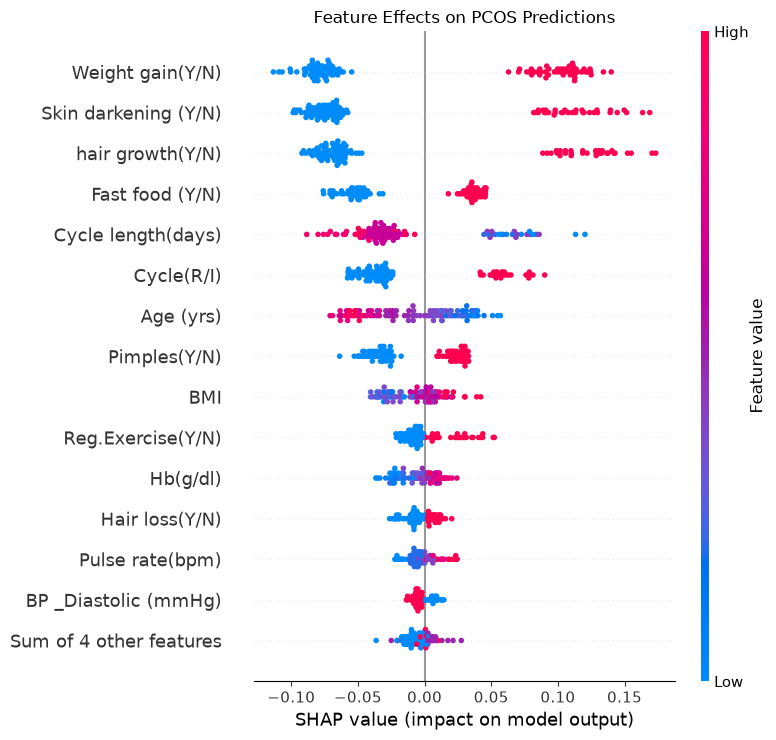

In [9]:
shap.plots.beeswarm(
    pcos_explanation,
    max_display=15,
    show=False
)

plt.title("Feature Effects on PCOS Predictions")
plt.tight_layout()
plt.show()

Predicted PCOS probability: 0.267
Actual label: 1


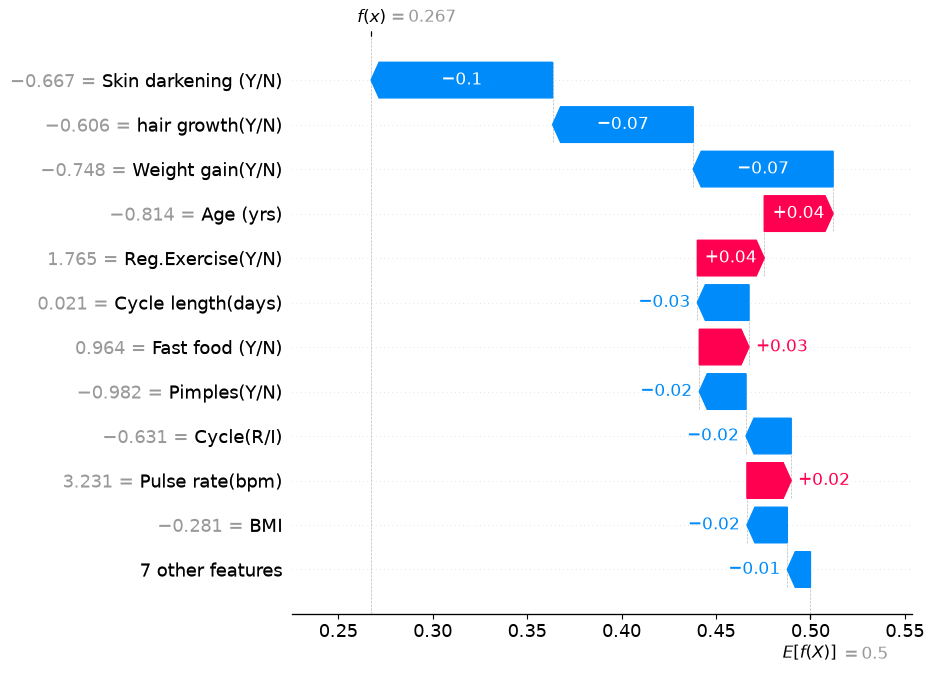

In [10]:
patient_index = 0

probability = best_random_forest.predict_proba(
    X_test.iloc[[patient_index]]
)[0, 1]

print("Predicted PCOS probability:", round(probability, 3))
print("Actual label:", y_test.iloc[patient_index])

shap.plots.waterfall(
    pcos_explanation[patient_index],
    max_display=12
)

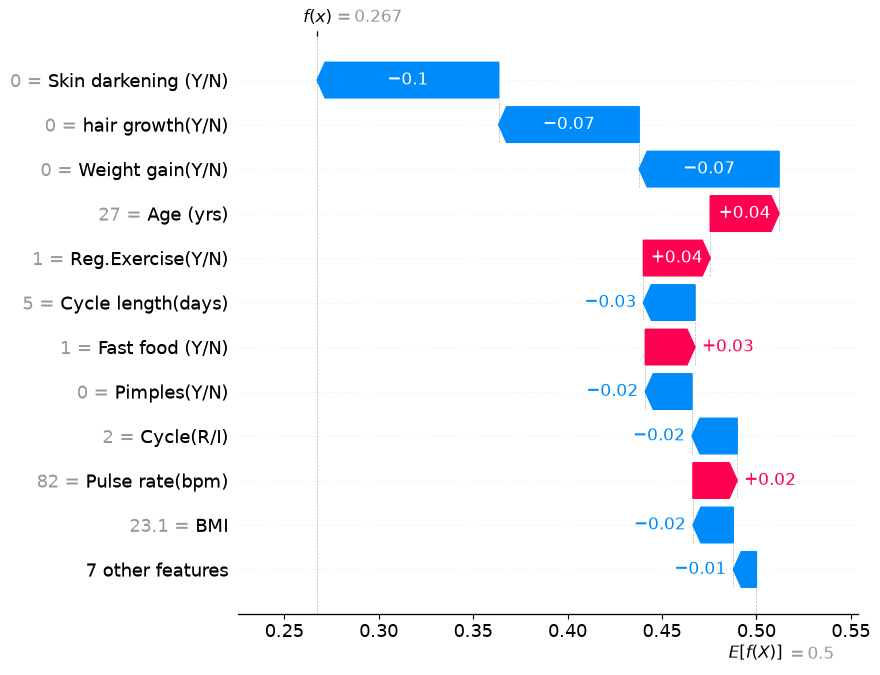

In [11]:
readable_explanation = shap.Explanation(
    values=pcos_explanation.values,
    base_values=pcos_explanation.base_values,
    data=X_test.to_numpy(),
    feature_names=features
)

shap.plots.waterfall(
    readable_explanation[patient_index],
    max_display=12
)

In [12]:
importance_df = pd.DataFrame({
    "feature": features,
    "mean_absolute_shap": np.abs(
        pcos_explanation.values
    ).mean(axis=0)
}).sort_values("mean_absolute_shap", ascending=False)

importance_df

,feature,mean_absolute_shap
6,Weight gain(Y/N),0.089840
8,Skin darkening (Y/N),0.087185
7,hair growth(Y/N),0.085414
11,Fast food (Y/N),0.045015
3,Cycle length(days),0.044347
2,Cycle(R/I),0.043399
0,Age (yrs),0.031531
10,Pimples(Y/N),0.029920
1,BMI,0.015602
12,Reg.Exercise(Y/N),0.013019


In [13]:
from pathlib import Path

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print(figures_dir)

c:\Users\Shreya Rathore\OneDrive\Desktop\PCOSense\reports\figures


In [14]:
importance_df.to_csv(
    project_root / "reports" / "shap_feature_importance.csv",
    index=False
)

print("SHAP importance table saved")

SHAP importance table saved


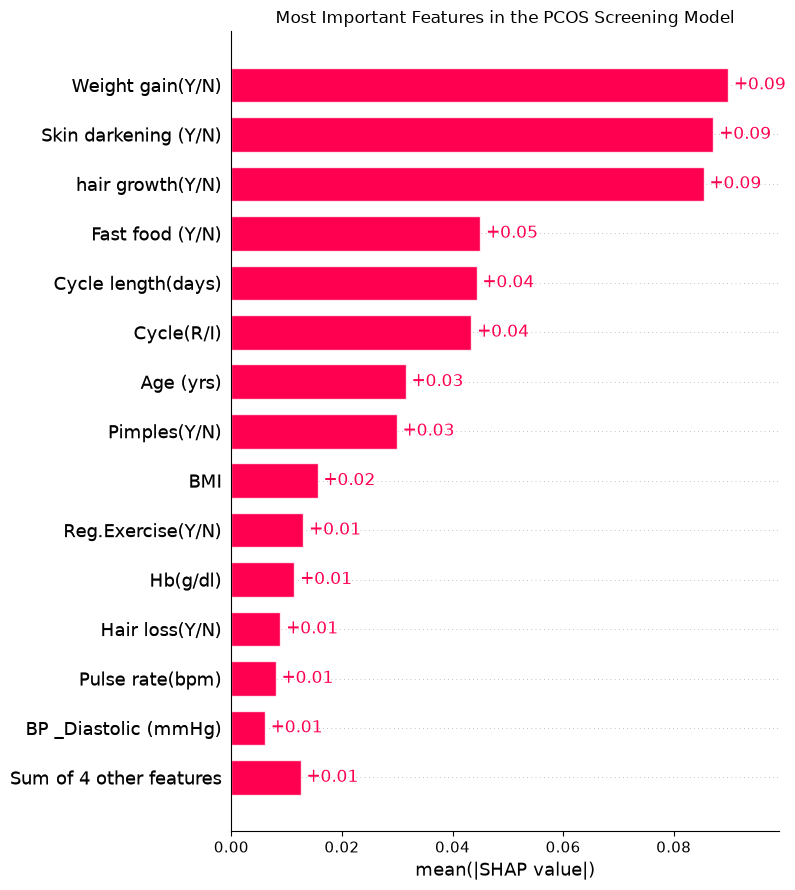

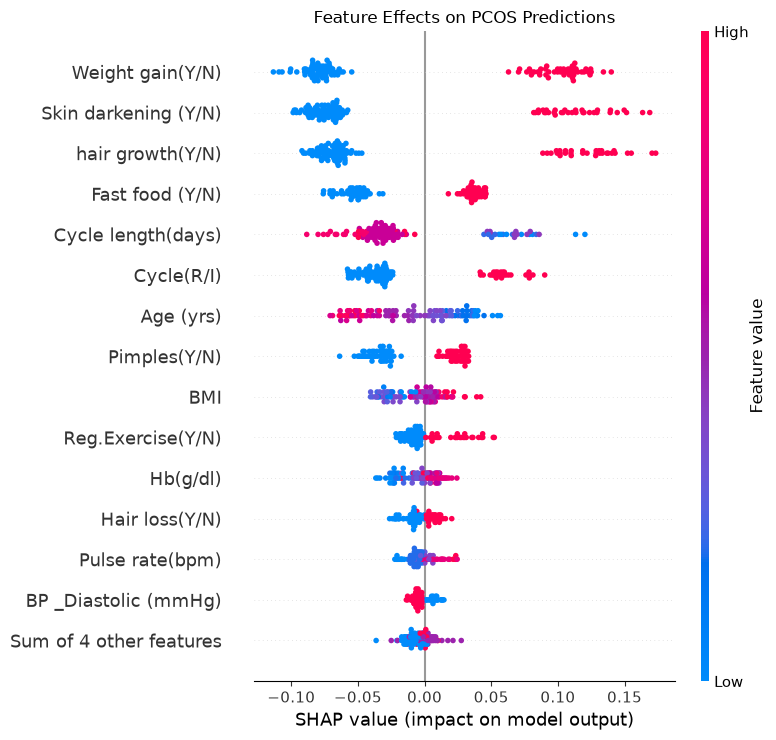

SHAP plots saved


In [15]:
shap.plots.bar(pcos_explanation, max_display=15, show=False)
plt.title("Most Important Features in the PCOS Screening Model")
plt.tight_layout()
plt.savefig(figures_dir / "shap_feature_importance.png", dpi=300)
plt.show()

shap.plots.beeswarm(pcos_explanation, max_display=15, show=False)
plt.title("Feature Effects on PCOS Predictions")
plt.tight_layout()
plt.savefig(figures_dir / "shap_summary.png", dpi=300)
plt.show()

print("SHAP plots saved")